In [1]:
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm


# feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *
from MODELS.pipeline import *

KeyboardInterrupt: 

In [ ]:
pd.set_option('display.max_columns', None)
epsilon = 1e-8

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
player_avg_minutes = s19.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
s19 = s19[s19['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s19['EXPECTED_USAGE_MIN'] = s19['USG_PCT_ROLLING_AVG_5'] * s19['MIN_ROLLING_AVG_5']

s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
player_avg_minutes = s20.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
s20 = s20[s20['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s20['EXPECTED_USAGE_MIN'] = s20['USG_PCT_ROLLING_AVG_5'] * s20['MIN_ROLLING_AVG_5']

s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
player_avg_minutes = s21.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
s21 = s21[s21['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s21['EXPECTED_USAGE_MIN'] = s21['USG_PCT_ROLLING_AVG_5'] * s21['MIN_ROLLING_AVG_5']

s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
player_avg_minutes = s22.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
s22 = s22[s22['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s22['EXPECTED_USAGE_MIN'] = s22['USG_PCT_ROLLING_AVG_5'] * s22['MIN_ROLLING_AVG_5']

s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
player_avg_minutes = s23.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
s23 = s23[s23['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s23['EXPECTED_USAGE_MIN'] = s23['USG_PCT_ROLLING_AVG_5'] * s23['MIN_ROLLING_AVG_5']

s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
player_avg_minutes = s24.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
s24 = s24[s24['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * s24['MIN_ROLLING_AVG_5']


s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
player_avg_minutes = s25.groupby('PLAYER_NAME')['MIN'].mean().reset_index()
player_avg_minutes.columns = ['PLAYER_NAME', 'AVG_MIN']
players_over_20_min = player_avg_minutes[player_avg_minutes['AVG_MIN'] > 20]
s25 = s25[s25['PLAYER_NAME'].isin(players_over_20_min['PLAYER_NAME'])]
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * s25['MIN_ROLLING_AVG_5']

train_df = pd.concat([s19, s20, s21, s22, s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df.tail()

: 

In [130]:
featuresV2 = [
    # Player context
    'GUARD', 'FORWARD', 'CENTER', 'STARTING', 'PLAYER_IS_TEAM_STAR', 'TEAM_STAR_OUT', 'NUM_USUAL_STARTERS_PRESENT', 

    # Game Context
    'HOME_GAME','PLAYER_DAYS_REST', 'IS_BACK_TO_BACK', 'TEAM_IMPLIED_PTS_FAV', 'TEAM_IMPLIED_PTS_UND',
    'spread', 'total', 'EXPECTED_PACE',
    
    # Player averages (season to date)
    'PTS_AVG_TO_DATE', 'MIN_AVG_TO_DATE', 'FGA_AVG_TO_DATE', 'USG_PCT_AVG_TO_DATE',
    'TS_PCT_AVG_TO_DATE', 'EFG_PCT_AVG_TO_DATE', 'PACE_AVG_TO_DATE', 'TCHS_AVG_TO_DATE',

    # Pts without star
    'PTS_WITHOUT_STAR', 'USG_PCT_WITHOUT_STAR', 'FGA_WITHOUT_STAR',
    
    # Home stats
    'PLAYER_HOME_AVG_PTS_TO_DATE', 'PLAYER_HOME_AVG_FGA_TO_DATE', 'PLAYER_HOME_AVG_USG_PCT_TO_DATE',
    
    # Recent performance (lags)
    'PTS_LAG_1', 'MIN_LAG_1', 'FGA_LAG_1',
    
    # Rolling form (short, medium, long horizons)
    'PTS_ROLLING_AVG_5', 'PTS_ROLLING_AVG_15', 'PTS_ROLLING_AVG_40',
    'MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_15', 'MIN_ROLLING_AVG_40',
    'FGA_ROLLING_AVG_5', 'FGA_ROLLING_AVG_15', 'FGA_ROLLING_AVG_40',
    'PACE_ROLLING_AVG_5', 'PACE_ROLLING_AVG_15', 'PACE_ROLLING_AVG_40',
    'POSS_ROLLING_AVG_5', 'POSS_ROLLING_AVG_15', 'POSS_ROLLING_AVG_40',
    'EFG_PCT_ROLLING_AVG_5', 'EFG_PCT_ROLLING_AVG_15', 'EFG_PCT_ROLLING_AVG_40',
    'TS_PCT_ROLLING_AVG_5', 'TS_PCT_ROLLING_AVG_15', 'TS_PCT_ROLLING_AVG_40',
    'USG_PCT_ROLLING_AVG_5', 'USG_PCT_ROLLING_AVG_15', 'USG_PCT_ROLLING_AVG_40',
    
    # Team Context
    'TEAM_OFF_RATING_AVG_TO_DATE', 'TEAM_PACE_AVG_TO_DATE', 'TEAM_PTS_AVG_TO_DATE',
    
    # Opponent Context
    'OPP_DEF_RATING_AVG_TO_DATE', 'OPP_PACE_AVG_TO_DATE', 'OPP_REB_AVG_TO_DATE', 'OPP_BLK_AVG_TO_DATE', 'OPP_STL_AVG_TO_DATE',

    # Opponent Context by position
    'OPP_GUARD_DEF_FG_PCT_ALLOWED', 'OPP_FORWARD_DEF_FG_PCT_ALLOWED', 'OPP_CENTER_DEF_FG_PCT_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN', 'OPP_FORWARD_PTS_ALLOWED_PER_MIN', 'OPP_CENTER_PTS_ALLOWED_PER_MIN',

    # Opponent Defensive Shot Profile (Season Averages)
    'OPP_CENTER_FREQ_LT_10','OPP_CENTER_LT_10_PCT',
    'OPP_FORWARD_FREQ_GT_15','OPP_FORWARD_GT_15_PCT',
    'OPP_GUARD_FREQ_FG3','OPP_GUARD_FG3_PCT_main'
] 


In [ ]:
featuresV2 = [
    # Player context
    'PLAYER_ID', 'TEAM_ID', 'OPP_TEAM_ID', 
    'GUARD', 'FORWARD', 'CENTER',
    'PLAYER_IS_TEAM_STAR', 'STARTING', 
    
    # Game context
    'HOME_GAME', 'PLAYER_DAYS_REST', 'IS_BACK_TO_BACK', 
    'whos_favored', 'spread', 'total', 'BLOWOUT_RISK', 
    
    # opponenet context
    'OPP_DEF_RATING_AVG_TO_DATE', 'OPP_PACE_AVG_TO_DATE', 'OPP_REB_AVG_TO_DATE', 
    'OPP_BLK_AVG_TO_DATE', 'OPP_STL_AVG_TO_DATE', 
    
    # Team context
    'TEAM_PACE_AVG_TO_DATE', 'TEAM_OFF_RATING_AVG_TO_DATE', 'TEAM_PTS_AVG_TO_DATE',
    'TEAM_DEF_RATING_AVG_TO_DATE',
    
    # Player form
    'PTS_ROLLING_AVG_5', 'PTS_ROLLING_AVG_7', 'PTS_ROLLING_AVG_15', 'PTS_ROLLING_AVG_25',
    'MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_7', 'MIN_ROLLING_AVG_15', 'MIN_ROLLING_AVG_25',
    'FGA_ROLLING_AVG_5', 'FG3A_ROLLING_AVG_5', 'FTA_ROLLING_AVG_5', 'POSS_ROLLING_AVG_5',
    'USG_PCT_ROLLING_AVG_5', 'TS_PCT_ROLLING_AVG_5', 'EFG_PCT_ROLLING_AVG_5',
    
    # Team situation
    'TEAM_STAR_OUT', 'NUM_USUAL_STARTERS_PRESENT',
    'PTS_WITHOUT_STAR', 'USG_PCT_WITHOUT_STAR', 'MIN_WITHOUT_STAR',
    'PLAYER_HOME_AVG_PTS_TO_DATE',
    
    # Pace
    'EXPECTED_PACE', 
    
    # Volatility Signals
    'PTS_VOLATILITY_5_TO_DATE','USG_PCT_VOLATILITY_5_TO_DATE', 'MIN_VOLATILITY_5_TO_DATE', 'FGA_VOLATILITY_5_TO_DATE',
    'FG3A_VOLATILITY_5_TO_DATE', 'FTA_VOLATILITY_5_TO_DATE',
]

: 

In [124]:
#     'percentageFieldGoalsAttempted3pt_ROLLING_AVG_5', 'percentageFieldGoalsAttempted3pt_ROLLING_AVG_15', 'percentageFieldGoalsAttempted3pt_ROLLING_AVG_40',
    # 'percentageFieldGoalsAttempted2pt_ROLLING_AVG_5', 'percentageFieldGoalsAttempted2pt_ROLLING_AVG_15', 'percentageFieldGoalsAttempted2pt_ROLLING_AVG_40',
    # 'percentagePoints3pt_ROLLING_AVG_5', 'percentagePoints3pt_ROLLING_AVG_15', 'percentagePoints3pt_ROLLING_AVG_40',
    # 'percentagePoints2pt_ROLLING_AVG_5', 'percentagePoints2pt_ROLLING_AVG_15', 'percentagePoints2pt_ROLLING_AVG_40',
    # 'percentagePointsPaint_ROLLING_AVG_5', 'percentagePointsPaint_ROLLING_AVG_15', 'percentagePointsPaint_ROLLING_AVG_40',

# XGBOOST MODEL

In [131]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

def build_recent_weights(df, player_col, recent_n=20, recent_weight=5.0):
    w = np.ones(len(df), dtype=float)
    idx = df.groupby(player_col, sort=False).tail(recent_n).index
    w[idx] = recent_weight
    return w

def clean_feature_dtypes(X, cat_cols):
    Xc = X.copy()
    for c in Xc.columns:
        if c in cat_cols:
            continue
        if Xc[c].dtype == "bool":
            Xc[c] = Xc[c].astype(int)
        elif not np.issubdtype(Xc[c].dtype, np.number):
            Xc[c] = pd.to_numeric(Xc[c], errors="coerce")
    return Xc

def xgb_params(base=None, use_gpu=False):
    p = dict(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method='hist',
        booster='gbtree',
        random_state=42,
        n_jobs=-1,
        
        n_estimators=5000,
        learning_rate=0.01, 
        max_depth=8,
        min_child_weight=8, #help balance overfitting vs underfitting   
        
        subsample=0.8,
        colsample_bytree=0.8,
        
        gamma=1,
        reg_alpha=1.0,
        reg_lambda=5.0,
        
        early_stopping_rounds=100, 
        verbosity=1
    )
    if base:
        p.update(base)
    if use_gpu:
        p["tree_method"] = "gpu_hist"
        p["gpu_id"] = 0
    return p

def fit_train_val(
    train_df, val_df,
    features, target_col, date_col, player_col,
    recent_n=40, recent_weight=3.0,
    params=None, use_gpu=False
):
    # sort by date to ensure chronological order
    train_df = train_df.sort_values(date_col).reset_index(drop=True)
    val_df = val_df.sort_values(date_col).reset_index(drop=True)

    X_tr = train_df[features]
    y_tr = train_df[target_col].to_numpy()
    X_va = val_df[features]
    y_va = val_df[target_col].to_numpy()

    # clean types (no categorical handling needed)
    X_tr = clean_feature_dtypes(X_tr, set())
    X_va = clean_feature_dtypes(X_va, set())

    # sample weights
    w_tr = build_recent_weights(train_df, player_col, recent_n, recent_weight)

    # Get parameters
    p = xgb_params(params, use_gpu=use_gpu)
    
    # Create model
    model = XGBRegressor(**p)
    
    # Fit with early stopping - removed early_stopping_rounds from here
    model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )

    best_iter = model.best_iteration if hasattr(model, 'best_iteration') else p["n_estimators"]

    # retrain final model on train+val
    p_final = xgb_params(params, use_gpu=use_gpu)
    p_final["n_estimators"] = int(best_iter)
    p_final.pop("early_stopping_rounds", None)  # Remove early_stopping_rounds for final model
    
    full_df = pd.concat([train_df, val_df], ignore_index=True)
    X_full = clean_feature_dtypes(full_df[features], set())
    y_full = full_df[target_col].to_numpy()
    
    w_full = np.concatenate([
        build_recent_weights(train_df, player_col, recent_n, recent_weight),
        np.ones(len(val_df))
    ])

    final_model = XGBRegressor(**p_final)
    final_model.fit(X_full, y_full, sample_weight=w_full, verbose=False)

    # validation metrics
    val_preds = model.predict(X_va)
    diff = val_preds - y_va
    val_rmse = float(np.sqrt(np.mean(diff**2)))
    val_mae = float(np.mean(np.abs(diff)))
    val_r2 = float(r2_score(y_va, val_preds))

    return final_model, dict(RMSE=val_rmse, MAE=val_mae, R2=val_r2, best_iteration=int(best_iter)), []

def evaluate_test(model, test_df, features, target_col, cat_cols):
    X_te = clean_feature_dtypes(test_df[features], set())
    y_te = test_df[target_col].to_numpy()
    
    preds = model.predict(X_te)
    diff = preds - y_te

    rmse = float(np.sqrt(np.mean(diff**2)))
    mae = float(np.mean(np.abs(diff)))
    r2 = float(r2_score(y_te, preds))

    residuals_df = pd.DataFrame({
        "actual": y_te,
        "predicted": preds,
        "residual": diff
    })
    
    # Join back some useful context for grouping
    context_cols = ["PLAYER_NAME", "MATCHUP", "TEAM_PTS", "OPP_PTS", "STARTING","PLAYER_IS_TEAM_STAR", "TEAM_STAR_OUT",'HOME_GAME', 'MIN']
    available_cols = [c for c in context_cols if c in test_df.columns]
    residuals_df = residuals_df.join(test_df[available_cols])
    
    return dict(RMSE=rmse, MAE=mae, R2=r2), residuals_df

In [132]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=featuresV2,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False
)

print("Validation metrics:", val_metrics)

test_metrics, residuals_df = evaluate_test(xgbModel, test_df, featuresV2, "PTS", used_cats)
print("Test metrics:", test_metrics)

Validation metrics: {'RMSE': 6.481418613675112, 'MAE': 5.045529490835473, 'R2': 0.48487138748168945, 'best_iteration': 642}
Test metrics: {'RMSE': 6.445023084025763, 'MAE': 5.057064897802774, 'R2': 0.46461379528045654}


In [133]:
feature_importance = pd.DataFrame({
    'feature': featuresV2,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 vs Bottom 25 Features - Side by Side")
print("=" * 100)

# Get top 25 and bottom 25
top25 = feature_importance.head(25).reset_index(drop=True)
bottom25 = feature_importance.tail(25).reset_index(drop=True)

# Reset index for bottom 25 to start from 0
bottom25 = bottom25.reset_index(drop=True)

# Create side-by-side comparison
comparison = pd.concat([
    top25.rename(columns={'feature': 'TOP_FEATURES', 'importance': 'TOP_IMPORTANCE'}),
    bottom25.rename(columns={'feature': 'BOTTOM_FEATURES', 'importance': 'BOTTOM_IMPORTANCE'})
], axis=1)

print(comparison.to_string(index=False))

Top 25 vs Bottom 25 Features - Side by Side
                  TOP_FEATURES  TOP_IMPORTANCE             BOTTOM_FEATURES  BOTTOM_IMPORTANCE
            PTS_ROLLING_AVG_15        0.273360         OPP_REB_AVG_TO_DATE           0.003410
            PTS_ROLLING_AVG_40        0.205178      OPP_GUARD_FG3_PCT_main           0.003365
               PTS_AVG_TO_DATE        0.097034      EFG_PCT_ROLLING_AVG_15           0.003363
            FGA_ROLLING_AVG_40        0.029602          TS_PCT_AVG_TO_DATE           0.003356
            FGA_ROLLING_AVG_15        0.026492         PACE_ROLLING_AVG_15           0.003350
           PLAYER_IS_TEAM_STAR        0.024642        TEAM_PTS_AVG_TO_DATE           0.003314
                      STARTING        0.020651        TS_PCT_ROLLING_AVG_5           0.003314
             FGA_ROLLING_AVG_5        0.018353             IS_BACK_TO_BACK           0.003304
                 TEAM_STAR_OUT        0.017185       EFG_PCT_ROLLING_AVG_5           0.003298
              PT

In [89]:
# Residuals analysis
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(30).reset_index(drop=True)
top25errors

,actual,predicted,residual,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,PLAYER_IS_TEAM_STAR,TEAM_STAR_OUT,HOME_GAME,MIN
0,0,25.314871,25.314871,Anthony Davis,LAL @ GSW,115,113.0,1,0,1,0,7.20
1,2,26.673046,24.673046,Trae Young,ATL vs. BOS,93,123.0,1,1,0,1,23.25
2,0,23.840021,23.840021,Jaren Jackson Jr.,MEM vs. ATL,130,132.0,1,0,1,1,1.65
3,5,27.703135,22.703135,Tyrese Maxey,PHI vs. GSW,126,119.0,1,0,1,1,39.82
4,3,25.409512,22.409512,Stephen Curry,GSW vs. HOU,96,106.0,1,0,1,1,32.67
5,5,27.331434,22.331434,Tyrese Maxey,PHI vs. TOR,103,106.0,1,0,0,1,34.07
6,4,26.237673,22.237673,Anthony Davis,LAL @ PHI,104,118.0,1,0,1,0,9.83
7,5,27.017878,22.017878,LaMelo Ball,CHA @ BKN,89,97.0,1,1,0,0,10.32
8,7,28.880348,21.880348,LaMelo Ball,CHA vs. LAL,107,112.0,1,1,0,1,8.75
9,4,25.795280,21.795280,Damian Lillard,MIL @ MEM,99,122.0,1,0,0,0,33.35


In [92]:
joblib.dump(xgbModel, 'xgbModel.pkl')

['xgbModel.pkl']

/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_29019/1302807732.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_29019/1302807732.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])


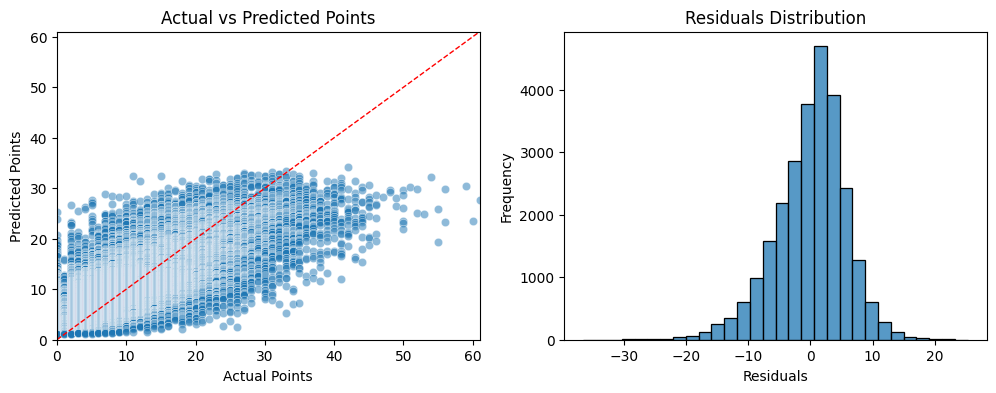

In [90]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Points')
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')

sns.histplot(residuals_df['residual'], bins=30, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()

- Currently my model isnt able to predict games were players score above 30+ points

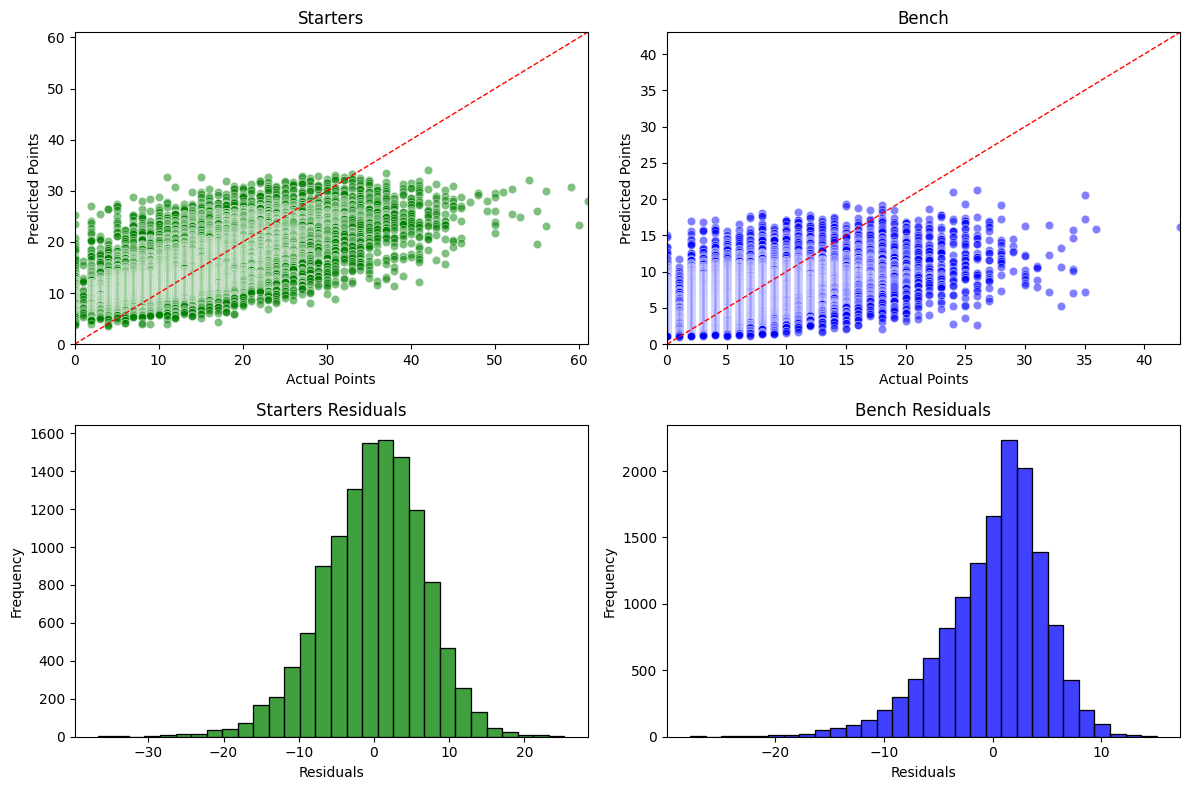

In [ ]:
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

sns.scatterplot(x='actual', y='predicted', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['predicted'].min())
maxVal = max(starters['actual'].max(), starters['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Starters')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['predicted'].min())
maxVal = max(bench['actual'].max(), bench['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Bench')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starters['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(bench['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()


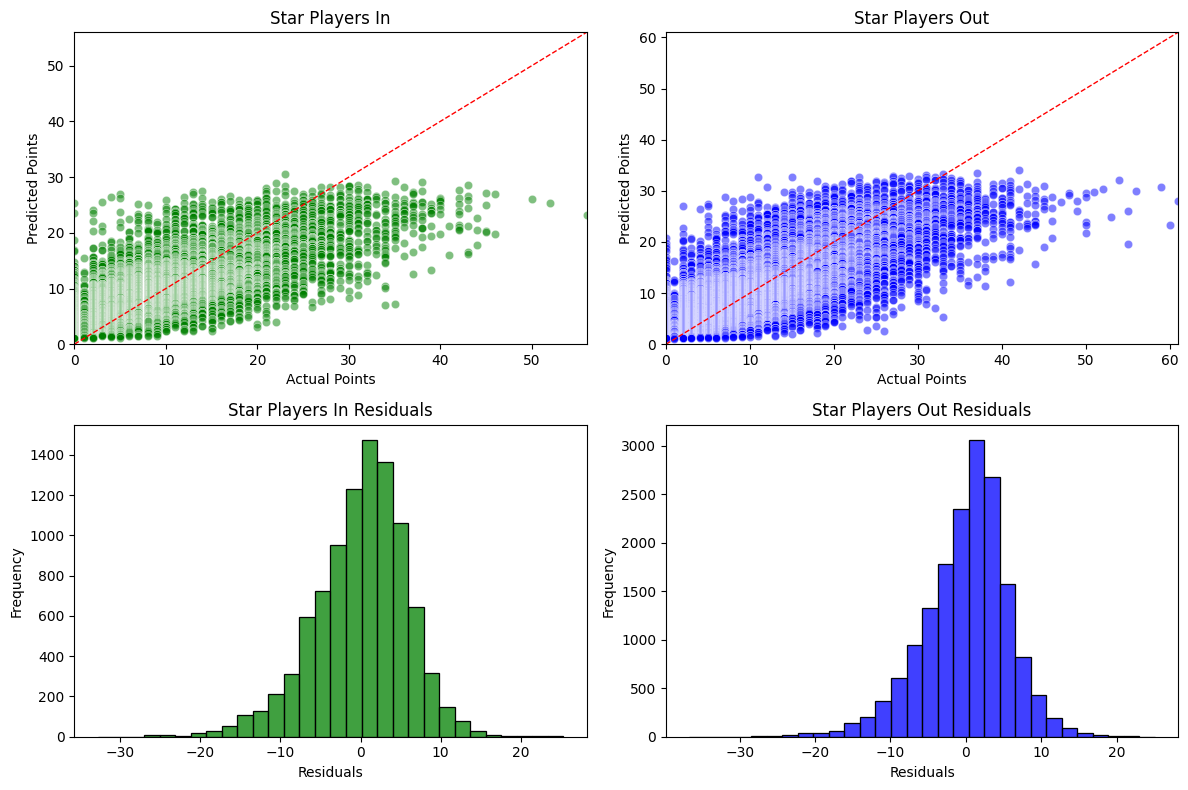

In [ ]:
starsIn = residuals_df[residuals_df['TEAM_STAR_OUT'] == 1]
starsOut = residuals_df[residuals_df['TEAM_STAR_OUT'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=starsIn, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starsIn['actual'].min(), starsIn['predicted'].min())
maxVal = max(starsIn['actual'].max(), starsIn['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Star Players In')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=starsOut, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(starsOut['actual'].min(), starsOut['predicted'].min())
maxVal = max(starsOut['actual'].max(), starsOut['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Star Players Out')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starsIn['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Star Players In Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(starsOut['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Star Players Out Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()



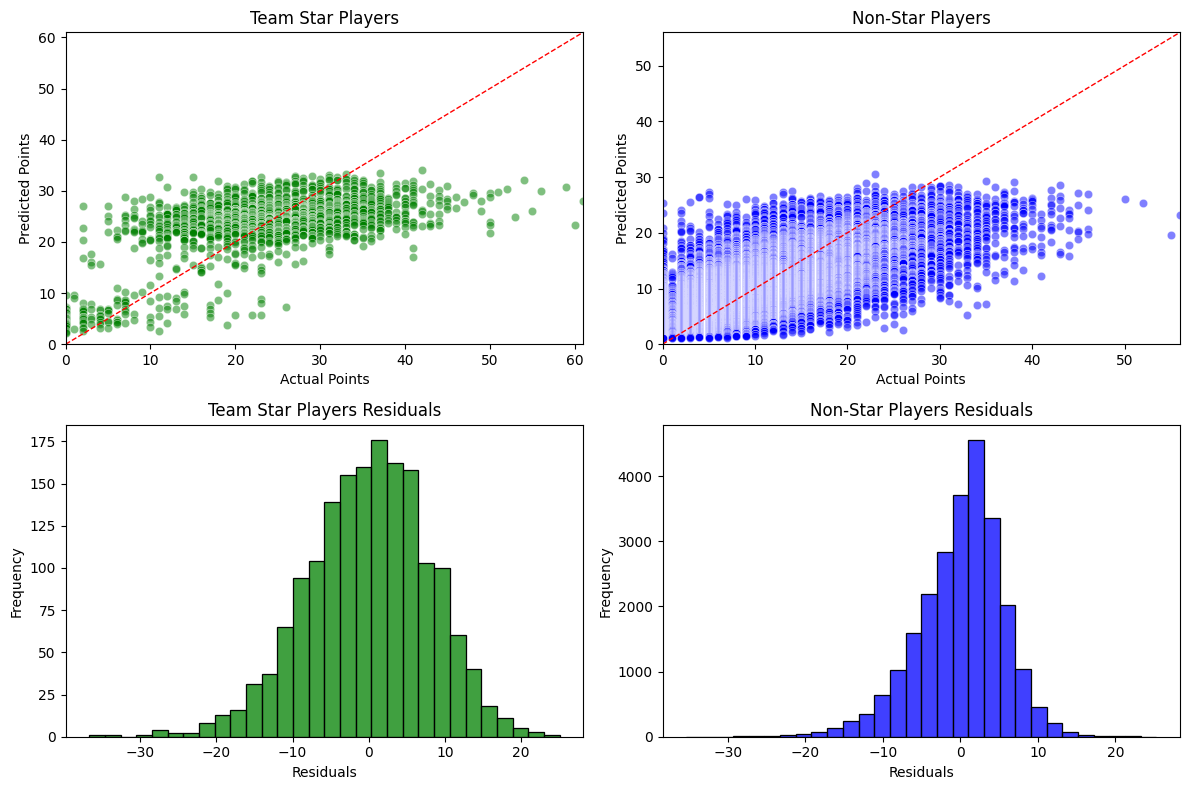

In [ ]:
starPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 1]
nonStarPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=starPlayers, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starPlayers['actual'].min(), starPlayers['predicted'].min())
maxVal = max(starPlayers['actual'].max(), starPlayers['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Team Star Players')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=nonStarPlayers, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(nonStarPlayers['actual'].min(), nonStarPlayers['predicted'].min())
maxVal = max(nonStarPlayers['actual'].max(), nonStarPlayers['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Non-Star Players')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starPlayers['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Team Star Players Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(nonStarPlayers['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Non-Star Players Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

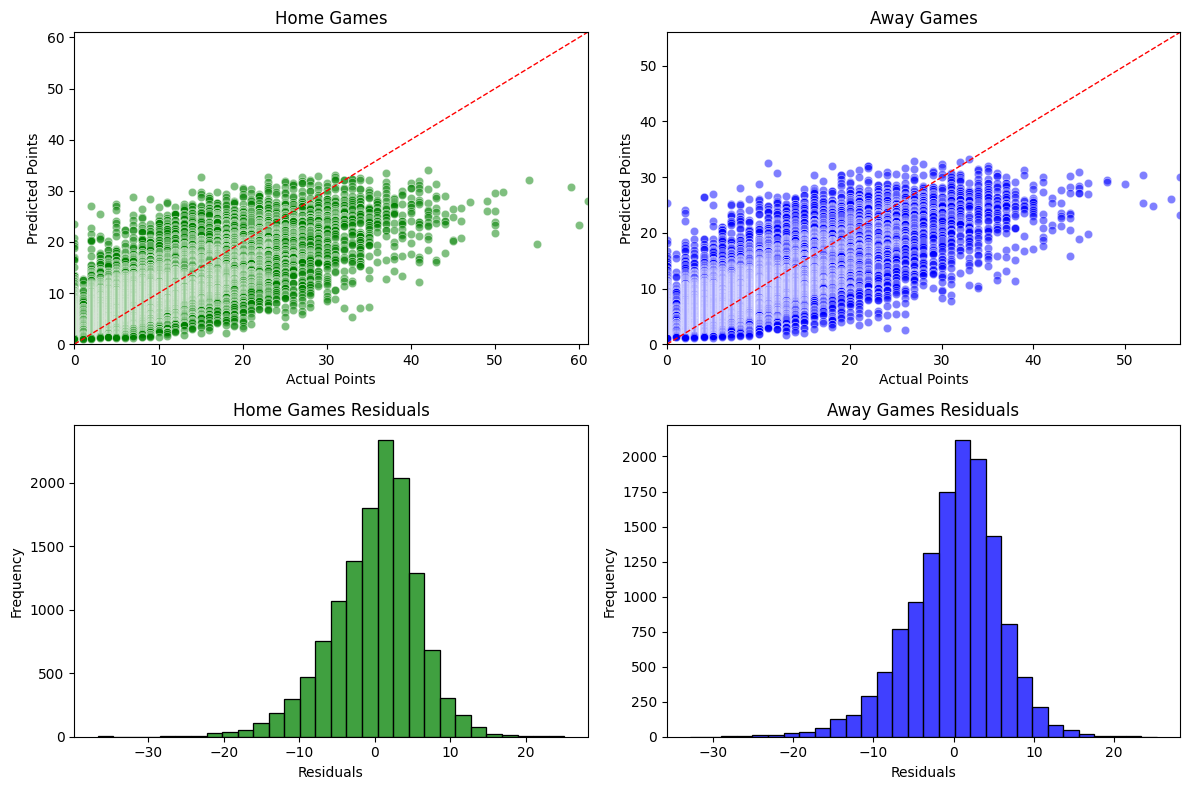

In [ ]:
homeGames = residuals_df[residuals_df['HOME_GAME'] == 1]
awayGames = residuals_df[residuals_df['HOME_GAME'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=homeGames, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(homeGames['actual'].min(), homeGames['predicted'].min())
maxVal = max(homeGames['actual'].max(), homeGames['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Home Games')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=awayGames, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(awayGames['actual'].min(), awayGames['predicted'].min())
maxVal = max(awayGames['actual'].max(), awayGames['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Away Games')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(homeGames['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Home Games Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(awayGames['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Away Games Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

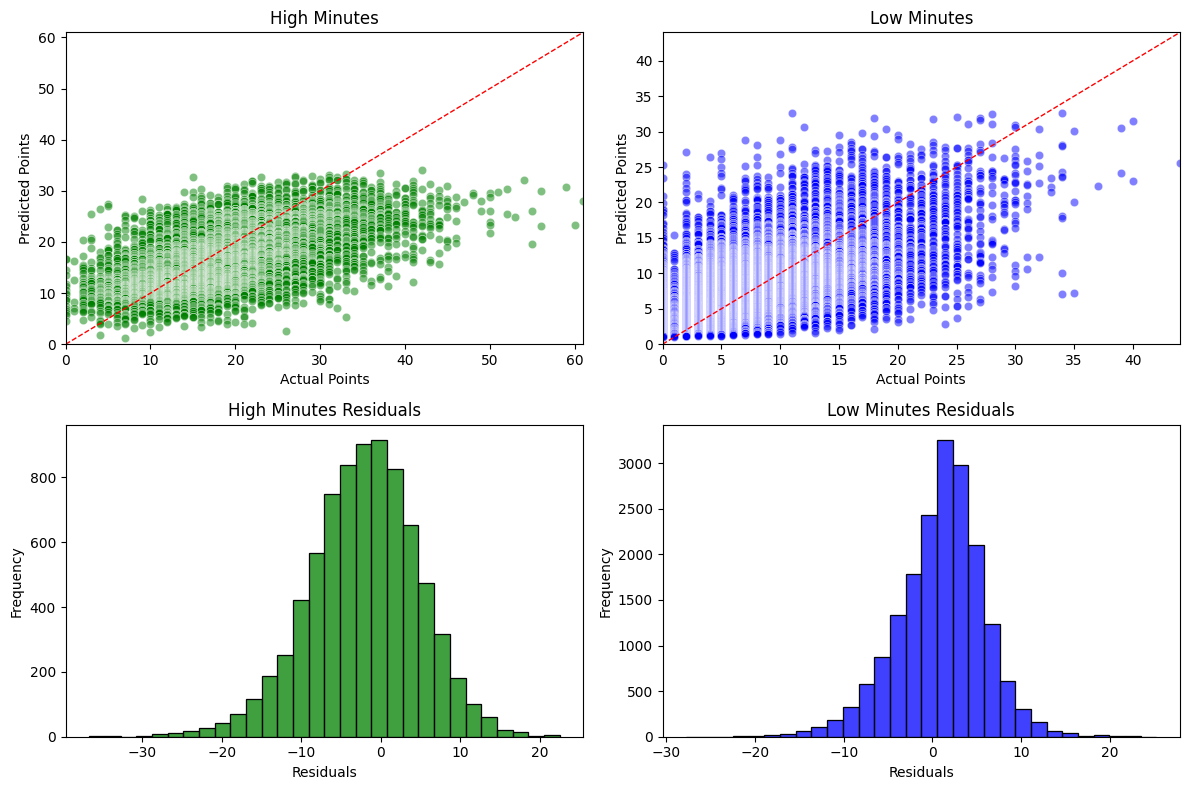

In [ ]:
highMins = residuals_df[residuals_df['MIN'] > 30]
lowMins = residuals_df[residuals_df['MIN'] <= 30]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=highMins, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(highMins['actual'].min(), highMins['predicted'].min())
maxVal = max(highMins['actual'].max(), highMins['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('High Minutes')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=lowMins, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(lowMins['actual'].min(), lowMins['predicted'].min())
maxVal = max(lowMins['actual'].max(), lowMins['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Low Minutes')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(highMins['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('High Minutes Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(lowMins['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Low Minutes Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()